### Differential protein analysis and biomarker identification

This notebook will walk through a differential protein identification analysis using real protein abundance data from three experimental conditions: DMSO, G0803 and G8255 (of which the latter two are both ATF6 inhibitors). 

We'll be using quantification files from the UCSD Center for Computational Mass Spectrometry. The data can be found [here](https://massive.ucsd.edu/ProteoSAFe/dataset_files.jsp?task=7234bdeaf654444caa72a6a23c9c5d67#%7B%22table_sort_history%22%3A%22main.collection_asc%22%7D) and is part of a [study](https://massive.ucsd.edu/ProteoSAFe/dataset.jsp?task=7234bdeaf654444caa72a6a23c9c5d67) that found ATF6 promotes colorectal cancer growth and stemness by regulating the Wnt pathway.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests



file_path = "/Users/aneesavalentine/Downloads/msstats_quant_results.txt"

df = pd.read_csv(file_path, sep='\t')

print(df.head())


   Mixture  TechRepMixture  Run Channel  Abundance BioReplicate Condition  \
0        1               1  1_1    126C  17.119045      DMSO_R1      DMSO   
1        1               1  1_1    126C  16.955454      DMSO_R1      DMSO   
2        1               1  1_1    126C  16.893429      DMSO_R1      DMSO   
3        1               1  1_1    126C  16.424709      DMSO_R1      DMSO   
4        1               1  1_1    126C  16.623145      DMSO_R1      DMSO   

          ProteinName    Intensity  IntensitySum  IntensityRatio  
0  1433B_HUMAN|P31946  142346.2346   1682427.364        0.084608  
1  1433E_HUMAN|P62258  127086.7583   1398764.242        0.090856  
2  1433F_HUMAN|Q04917  121738.7564   1408020.250        0.086461  
3  1433G_HUMAN|P61981   87969.0853   1032766.122        0.085178  
4  1433S_HUMAN|P31947  100940.4814   1408466.564        0.071667  


In [44]:
print(df['Condition'].unique())

['DMSO' 'G0803' 'G8255']


In [45]:
df.shape

(98532, 11)

Pivot to create protein matrix: protein x sample.

In [46]:
protein_matrix = df.pivot_table(index='ProteinName', columns='BioReplicate', values='Intensity')

In [47]:
protein_matrix

BioReplicate,DMSO_R1,DMSO_R2,DMSO_R3,DMSO_R4,G0803_R1,G0803_R2,G0803_R3,G8255_R1,G8255_R2,G8255_R3,G8255_R4
ProteinName,,,,,,,,,,,
1433B_HUMAN|P31946,142346.23460,137405.10400,142708.13910,145162.18840,146548.53950,139312.86120,146364.53710,169321.30340,174165.23680,164762.49150,174330.72860
1433E_HUMAN|P62258,127086.75830,126410.80670,125049.92490,124175.17650,124212.57720,120952.70930,120705.77910,133533.33470,139373.63490,121553.24060,135710.29960
1433F_HUMAN|Q04917,121738.75640,128126.24070,126539.35760,124805.48050,133212.30680,128046.24300,133309.00220,130229.88870,132156.08910,123627.98260,126228.90270
1433G_HUMAN|P61981,87969.08530,88005.54026,85874.03521,83320.28412,92336.02982,79130.70679,84733.03384,108991.52640,120499.21370,100566.74930,101339.91680
1433S_HUMAN|P31947,100940.48140,100363.16430,104627.98080,107648.91800,110187.80000,114848.41310,108624.14200,159325.91700,177397.66120,154295.37510,170206.71080
...,...,...,...,...,...,...,...,...,...,...,...
ZY11A_HUMAN|Q6WRX3,73456.84400,79108.57482,83987.16894,72432.87620,74883.70000,64765.83816,69088.95887,124449.80820,112738.65300,144082.41210,111963.77680
ZY11B_HUMAN|Q9C0D3,23514.18837,24425.81780,26657.82938,24823.55820,28958.69827,25659.85955,25860.37929,27698.40490,27293.37767,28714.48280,30525.57430
ZYX_HUMAN|Q15942,159497.21880,151933.22140,152790.58280,140361.24860,155654.56110,150522.56560,158613.15110,172938.21090,167895.87870,166295.71470,163955.67170


In [ ]:
# exclude the 'BioReplicate' column from transformation
log_transformed = protein_matrix.applymap(lambda x: np.log2(x) if x > 0 else np.nan)

/var/folders/bd/djhgjhzs6rx_1ffvlb2ncd8c0000gn/T/ipykernel_85532/2933529239.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  log_transformed = protein_matrix.applymap(lambda x: np.log2(x) if x > 0 else np.nan)


In [ ]:
# normalize across columns (samples)
normalized = log_transformed.subtract(log_transformed.median(axis=0), axis=1)

Perform statistical testing.

In [ ]:
# define control and treatment groups based on `BioReplicate` col names
control_cols = [col for col in normalized.columns if col.startswith("DMSO")]
treatment_cols = [col for col in normalized.columns if col.startswith("G0803") or col.startswith("G8255")]

results = []

# iterate through each protein
for protein in normalized.index:
    control_vals = normalized.loc[protein, control_cols].dropna()
    treat_vals = normalized.loc[protein, treatment_cols].dropna()

    # perform t-test only if > 2 replicates are present
    if len(control_vals) > 1 and len(treat_vals) > 1:
        stat, pval = ttest_ind(treat_vals, control_vals, equal_var=False)
        log2fc = treat_vals.mean() - control_vals.mean()  # Assuming data is log2-transformed
        results.append({
            'Protein_ID': protein,
            'log2_FC': log2fc,
            'pval': pval
        })

# Convert to DataFrame
res_df = pd.DataFrame(results)



Adjust for multiple testing.

In [51]:
from statsmodels.stats.multitest import multipletests

res_df['FDR'] = multipletests(res_df['pval'], method='fdr_bh')[1]



Filter significant proteins.

In [52]:
sig_hits = res_df[(res_df['FDR'] < 0.05) & (abs(res_df['log2_FC']) > 1)]
print(sig_hits.sort_values('FDR'))

              Protein_ID   log2_FC      pval       FDR
8287  TYSD1_HUMAN|Q2T9J0 -1.025168  0.000017  0.010886
3242  HMCS1_HUMAN|Q01581  1.013442  0.000260  0.048464


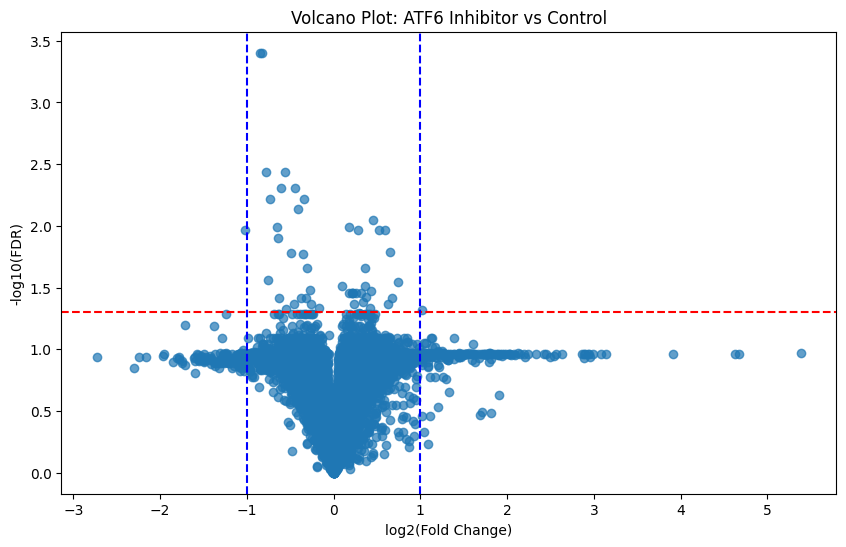

In [ ]:
res_df['-log10(FDR)'] = -np.log10(res_df['FDR'])

plt.figure(figsize=(10,6))
plt.scatter(res_df['log2_FC'], res_df['-log10(FDR)'], alpha=0.7)
plt.axhline(-np.log10(0.05), color='red', linestyle='--')
plt.axvline(1, color='blue', linestyle='--')
plt.axvline(-1, color='blue', linestyle='--')
plt.xlabel('log2(Fold Change)')
plt.ylabel('-log10(FDR)')
plt.title('Volcano Plot: ATF6 Inhibitor vs Control')
plt.show()
